<a href="https://colab.research.google.com/github/carpinetti/2025A-CPGINV-HPC-0012/blob/main/HandsOn01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Universidade SENAI CIMATEC**
**Disciplina 98901 CPGINV-HPC-0012 Fundamentos da Computação Quântica**

**Prof.º Gubio Gomes de Lima**

 **GRUPO 1: Anderson Garcia;
         Joseane de Almeida;
         Ézio Rego;
         Pedro Neves;**

Instala depêndencias:
* qiskit - É o "motor" principal. É a biblioteca da IBM que permite criar, simular e rodar programas em computadores quânticos usando a linguagem Python.
* qiskit-aer: É o nosso simulador quântico. Rodar programas em um computador quântico real da IBM pode exigir entrar em filas de espera. O Aer permite que o nosso próprio computador clássico (ou servidor) simule instantaneamente como o circuito vai se comportar.
* pylatexenc - Nosso tradutor de símbolos. Ele serve apenas para que símbolos matemáticos (como o $\pi$ ou letras gregas) apareçam desenhados corretamente nos diagramas, deixando o visual profissional.
* matplotlib: O "desenhista". É a biblioteca padrão do Python para gerar gráficos. O Qiskit a utiliza para transformar o código do circuito em uma imagem colorida e fácil de entender.

In [1]:
!pip install qiskit qiskit-aer pylatexenc matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 83.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 95.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 103.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.8 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=a65d1d5749a2a42bfd56f73485319aeb51138914f7f03b022c46eb0f8f7d4313
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


# Circuito quântico com 1 qubit

### Objetivo:
Demonstrar a evolução do estado de um único qubit por meio da aplicação sequencial de portas quânticas de superposição, fase, operação Pauli e rotações.

### Estado inicial:
Todo qubit em Qiskit é inicializado, por padrão, no estado |0⟩.

Neste circuito, o qubit passa pelas seguintes transformações:
1. H       -> cria superposição equiprovável;
2. S       -> altera a fase relativa do componente |1⟩;
3. Y       -> aplica a porta Pauli-Y, afetando estado e fase;
4. Rx(π/4) -> rotaciona o estado em 45° ao redor do eixo X;
5. Ry(π)   -> rotaciona o estado em 180° ao redor do eixo Y.

---

Circuito A - Estado inicial:
Statevector([1.+0.j, 0.+0.j],
            dims=(2,))

Após porta H:
Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))

Após porta S:
Statevector([0.70710678+0.j        , 0.        +0.70710678j],
            dims=(2,))

Após porta Y:
Statevector([0.70710678+0.j        , 0.        +0.70710678j],
            dims=(2,))

Após porta Rx(pi/4):
Statevector([0.92387953+0.j        , 0.        +0.38268343j],
            dims=(2,))

Após porta Ry(pi):
Statevector([5.65713056e-17-3.82683432e-01j,
             9.23879533e-01+2.34326020e-17j],
            dims=(2,))
Circuito A com medição:


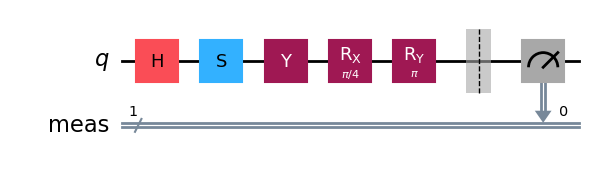

In [12]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
from math import pi
import matplotlib.pyplot as plt
%matplotlib inline

# ==================================================================
# 1. Circuito A - Cria um circuito quântico de 1 qubit com aplicação
# aplicação das portas Hadamard, fase S, Pauli-Y, e as portas rotacionais
# Rx e Ry
# ==================================================================
qcA = QuantumCircuit(1)

# ==================================================================
# Estado inicial do circuito A
# ==================================================================
print("============================================================")
print("Circuito A - Estado inicial:")
print("============================================================")

# O Statevector representa o vetor de estado quântico do sistema.
# Cada componente complexa corresponde à amplitude de probabilidade
# associada aos estados da base computacional.
#
# O módulo ao quadrado de cada amplitude fornece
# a probabilidade de medição do estado correspondente.

print(Statevector.from_instruction(qcA))

# O estado inicial do qubit é |0⟩.
# o vetor [1,0] indica que a probabilidade de medir |0⟩ é 100%.
# Não existe superposição neste momento.

# ==================================================================
# Porta Hadamard
# Cria superposição quântica
# Estado antes: |0⟩
#
# Estado após: (|0⟩ + |1⟩)/√2
# ==================================================================
# Aplica a porta Hadamard no qubit 0.
# Após essa operação, se o qubit fosse medido imediatamente,
# haveria 50% de probabilidade para |0⟩ e 50% para |1⟩.
qcA.h(0)

print("\nApós porta H:")
print(Statevector.from_instruction(qcA))


# ==================================================================
# Porta de fase S
# ==================================================================
# A porta S altera a fase do estado |1⟩.
# A porta S aplicada no qubit 0.
#
# Estado antes: (|0⟩ + |1⟩)/√2
#
# Estado após: (|0⟩ + i|1⟩)/√2
#
# Ela mantém |0⟩ inalterado e adiciona uma fase i ao estado |1⟩:
# Essa operação não altera diretamente as probabilidades de medição,
# mas altera a fase relativa entre os componentes do estado.
qcA.s(0)

print("\nApós porta S:")
print(Statevector.from_instruction(qcA))

# =================================================================
# Porta Pauli-Y
# =================================================================
# A porta Y combina inversão de estado com alteração de fase.
#
# Y|0⟩ = i|1⟩
# Y|1⟩ = -i|0⟩
#
# Aplica a porta Pauli-Y no qubit 0.
# A porta Y combina inversão de estado com alteração de fase:
# Essa porta atua simultaneamente sobre as amplitudes e as fases.
qcA.y(0)

print("\nApós porta Y:")
print(Statevector.from_instruction(qcA))

# ================================================================
# Porta Rx(pi/4)
# ================================================================
# A porta Rx realiza rotação Rx(π/4) no qubit 0 em torno do
# eixo X da esfera de Bloch.
#
# A porta Rx(θ) representa uma rotação do estado quântico em torno
# do eixo X da esfera de Bloch.
qcA.rx(pi/4, 0)

print("\nApós porta Rx(pi/4):")
print(Statevector.from_instruction(qcA))

# =================================================================
# Porta  Ry(π)
# =================================================================
# A porta Ry realiza rotação no qubit 0.
#
# A porta Ry(θ) representa uma rotação em torno do eixo Y da esfera de Bloch.
# Para θ = π, a porta Ry tem comportamento semelhante a uma inversão
# entre |0⟩ e |1⟩, mas com alteração de sinal em uma das componentes.
qcA.ry(pi, 0)

print("\nApós porta Ry(pi):")
print(Statevector.from_instruction(qcA))

# =================================================================
# Estados finais para visualização dos circuitos na esfera de Bloch
# =================================================================
# Visualização do circuito A na esfera de Bloch.
stateA = Statevector.from_instruction(qcA);

# =================================================================
# Medições finais
# =================================================================
# A medição colapsa o estado quântico.
# Portanto, ela é realizada somente ao final.

qcA.measure_all()

# =================================================================
# Visualização dos circuitos
# =================================================================
# Desenho do circuito A
drawA = qcA.draw('mpl');

# =================================================================
# Circuitos finais com medição
# =================================================================
print("============================================================")
print("Circuito A com medição:")
print("============================================================")
display(drawA)
plt.close()




# Circuito B com dois qubits

### Objetivo:
Demonstrar operações em um sistema de dois qubits, incluindo:

1. inversão de estado com porta Pauli-X;
2. criação de superposição com Hadamard;
3. criação de emaranhamento com CNOT;
4. transformação de base com uma nova Hadamard;
5. rotação Ry(π) aplicada ao segundo qubit.

### Estado inicial:
Como o circuito possui 2 qubits, o estado inicial padrão é |00⟩.
### Observação importante:
Na explicação conceitual, é comum escrever os estados como |q0 q1⟩.

Porém, internamente e ao exibir resultados, o Qiskit adota convenções de ordenação que podem parecer invertidas, especialmente em medições.

Por isso, ao interpretar resultados, é importante observar a ordem dos qubits no circuito.

---


Circuito B - Estado inicial
Statevector([1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2))

Após porta X:
Statevector([0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2))

Após porta H:
Statevector([ 0.70710678+0.j, -0.70710678+0.j,  0.        +0.j,
              0.        +0.j],
            dims=(2, 2))
Circuito B antes da CNOT na esfera de Bloch:


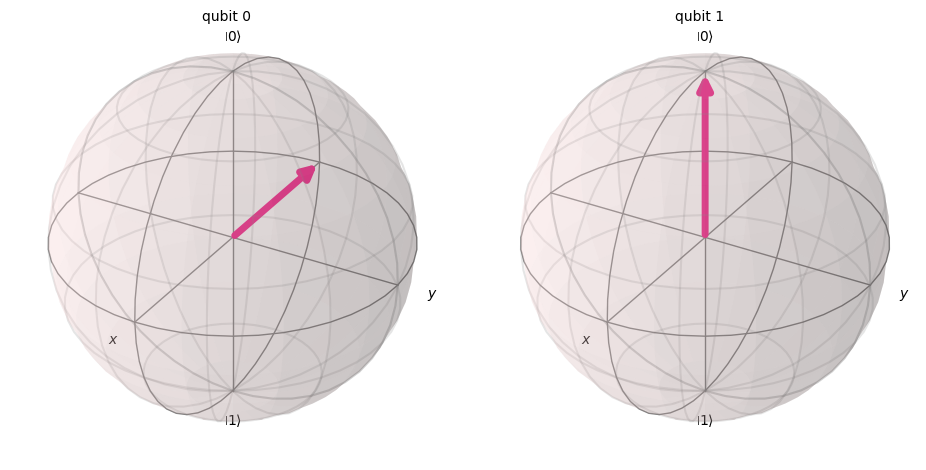


Após porta CNOT:
Statevector([ 0.70710678+0.j,  0.        +0.j,  0.        +0.j,
             -0.70710678+0.j],
            dims=(2, 2))

Após segunda porta H:
Statevector([ 0.5+0.j,  0.5+0.j, -0.5+0.j,  0.5+0.j],
            dims=(2, 2))

Após porta Ry(pi):
Statevector([ 0.5+0.j, -0.5+0.j,  0.5+0.j,  0.5+0.j],
            dims=(2, 2))
Circuito B:


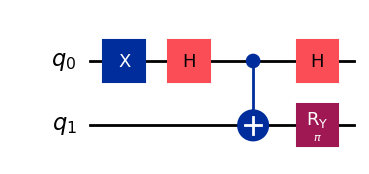

Circuito B na esfera de Bloch:


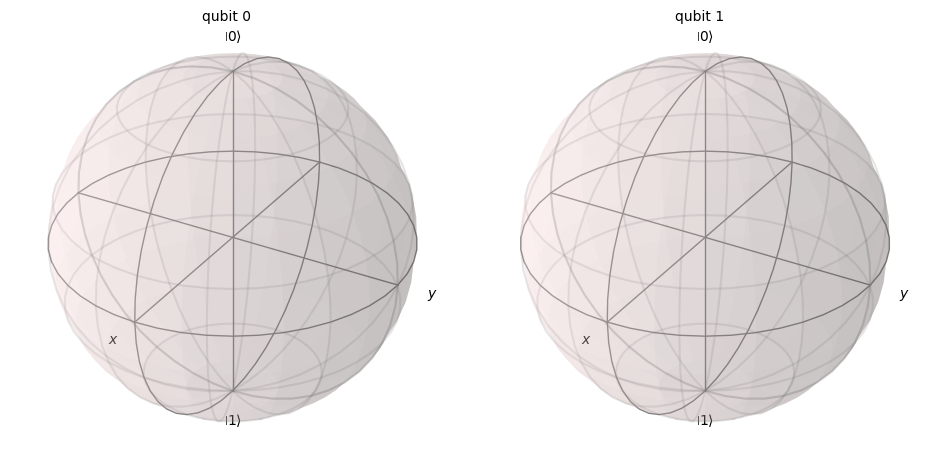

Circuito B com medição:


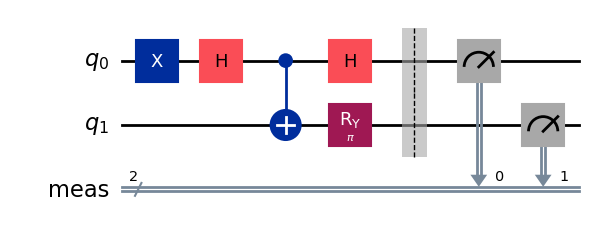

In [18]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
from math import pi
import matplotlib.pyplot as plt
%matplotlib inline

# =================================================================
# Circuito B - Circuito quântico de dois qubits
# =================================================================
# Circuito com:
# - superposição
# - emaranhamento
# - transformação de base
# - rotação Ry
# =================================================================

qcB = QuantumCircuit(2)

# =================================================================
# Estado inicial do Circuito B
# =================================================================
print("\n====================================")
print("Circuito B - Estado inicial")
print("====================================")

print(Statevector.from_instruction(qcB))

# ==========================================================
# Porta Pauli-X
# ==========================================================
# Aplica a porta Pauli-X no qubit 0.
# A porta X funciona como um NOT quântico:
# transforma |0⟩ em |1⟩ e |1⟩ em |0⟩.
# Estado inicial: |00⟩
# Estado após X(0): |10⟩, considerando a leitura conceitual |q0 q1⟩.

qcB.x(0)

print("\nApós porta X:")
print(Statevector.from_instruction(qcB))

# ==========================================================
# Porta Hadamard
# ==========================================================
# Aplica a porta Hadamard no qubit 0.
# A porta H coloca o qubit 0 em superposição.
# Como q0 estava em |1⟩, temos:
# H|1⟩ = (|0⟩ - |1⟩)/√2
# Estado após (|00⟩ - |10⟩)/√2

qcB.h(0)

print("\nApós porta H:")
print(Statevector.from_instruction(qcB))

# ==========================================================
# Visualização antes do emaranhamento
# ==========================================================
# Neste ponto os qubits ainda NÃO estão emaranhados.
# Portanto, os vetores podem ser visualizados normalmente
# na esfera de Bloch.

state_temp = Statevector.from_instruction(qcB)

print("============================================================")
print("Circuito B antes da CNOT na esfera de Bloch:")
print("============================================================")
display(plot_bloch_multivector(state_temp))
plt.close()

# ==========================================================
# Porta CNOT
# ==========================================================
# Funcionamento da CNOT:
#
# CNOT|00⟩ = |00⟩
# CNOT|01⟩ = |01⟩
# CNOT|10⟩ = |11⟩
# CNOT|11⟩ = |10⟩
#
# Aplica uma porta CNOT com q0 como controle e q1 como alvo.
# Se q0 = 1, a porta X é aplicada em q1.
# Se q0 = 0, q1 permanece inalterado.
#
# Como q0 está em superposição, a CNOT cria correlação quântica
# entre os dois qubits, resultando em um estado emaranhado:
#
# (|00⟩ - |11⟩) / √2
#
# Esse estado é equivalente ao estado de Bell Φ⁻.
qcB.cx(0, 1)

print("\nApós porta CNOT:")
print(Statevector.from_instruction(qcB))

# ==========================================================
# Segunda porta Hadamard
# ==========================================================
#
# Aplica novamente a porta Hadamard no qubit 0.
#
# Essa operação altera a base computacional
# e redistribui as amplitudes quânticas,
# Ou seja, a operação altera a base de q0 e transforma o estado emaranhado
# em uma nova combinação linear envolvendo os quatro estados da base:
# |00⟩, |01⟩, |10⟩ e |11⟩.
#
# Após essa operação, todos os estados passam a ter amplitudes
# de mesmo módulo, mas com fases relativas diferentes.
qcB.h(0)

print("\nApós segunda porta H:")
print(Statevector.from_instruction(qcB))

# ==========================================================
# Porta Ry(pi)
# ==========================================================
# Aplica uma rotação Ry(π) no qubit 1.
# A porta Ry representa uma rotação em torno do eixo Y da esfera de Bloch.
# Ou seja, ela troca os estados |0⟩ e |1⟩ do qubit 1,
# introduzindo também uma diferença de fase em uma das componentes.
qcB.ry(pi, 1)

print("\nApós porta Ry(pi):")
print(Statevector.from_instruction(qcB))

# =================================================================
# Visualização dos circuitos
# =================================================================
# Desenha o circuito B
drawB=qcB.draw(output='mpl');

# =================================================================
# Estados finais para visualização dos circuitos na esfera de Bloch
# =================================================================
# Visualização do circuito B na esfera de bloch.
stateB = Statevector.from_instruction(qcB)

# =================================================================
# Exibição dos circuitos
# =================================================================
print("Circuito B:")
display(drawB)
plt.close()

# ==========================================================
# Observação sobre o Circuito B
# ==========================================================
# No circuito B, após a aplicação da porta CNOT,
# os qubits tornam-se emaranhados.
#
# Em estados emaranhados, os qubits individuais
# deixam de possuir descrição independente.
#
# Por esse motivo, a esfera de Bloch pode não exibir
# vetores definidos para cada qubit separadamente,
# caracterizando estados mistos reduzidos.

print("Circuito B na esfera de Bloch:");
display(plot_bloch_multivector(stateB))
plt.close()

# =================================================================
# Medições finais
# =================================================================
# A medição colapsa o estado quântico.
# Portanto, ela é realizada somente ao final.
qcB.measure_all()

# =================================================================
# Circuitos finais com medição
# =================================================================
print("============================================================")
print("Circuito B com medição:")
print("============================================================")
display(qcB.draw('mpl'))
plt.close()
